This project focuses on analyzing video game sales data to identify patterns that contribute to a game's success. The analysis utilizes historical data from 2016 to forecast trends and inform advertising strategies for 2017.
Steps Completed

Step 1

Dataset Overview
Investigated the dataset located at /datasets/games.csv, which includes various attributes such as platform, genre, sales figures, critic scores, and user scores.

Step 2

Data Cleaning
Converted column names to lowercase for consistency.
Adjusted data types as necessary (e.g., converting sales figures to numeric).
Addressed missing values.
Calculated total sales by summing regional sales into a new column.

Step 3

Sales Distribution
Analyzed the number of games released annually and their sales across platforms.
Identified leading platforms and examined sales growth or decline over time.
Created box plots to compare global sales by platform and scatter plots to explore the relationship between reviews and sales.

Step 4: 

Regional User Profiles
Determined the top five platforms and genres in North America, Europe, and Japan, highlighting regional differences.

Step 5: 

Hypothesis Testing
Formulated and tested hypotheses regarding user ratings for Xbox One vs. PC and differences in ratings between Action and Sports genres, using an appropriate significance level.

Step 6

Conclusions
Summarized findings from the analysis, providing insights into sales trends, user preferences, and potential marketing strategies.

## Preparing the Data

### Opening the Data File and Studying General Information

In [1]:
# Importing necessary libraries:
import pandas as pd
import scipy as stats
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
# Loading the data set:
games_df = pd.read_csv("/datasets/games.csv")

In [3]:
# Printing the first five rows of the datat frame to understand the data structure
games_df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
# changing the column names to lower case:
games_df.columns =games_df.columns.str.lower()
games_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [5]:
# Getting basic information about the data:
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Preparing The Data for Analysis

#### Converting the Data Types | Fixing Missing Values | Checking for Duplicates | Checking for Unique Values

In [6]:
# Converting the "year_of_release" column to "Int64" type. 

games_df['year_of_release'] = games_df['year_of_release'].astype('Int64')
games_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


In [7]:
# Checking for and fixing nonnumeric values in the numerical type columns:

games_df['user_score'] = pd.to_numeric(games_df['user_score'], errors="coerce")


In [8]:
# Running an overview of the numeric type columns to verify that the changes have been applied

nan_counts = games_df[['year_of_release','user_score', 'critic_score', 'other_sales', 'jp_sales', 'eu_sales', 'na_sales']].isna().sum()
print(nan_counts)

year_of_release     269
user_score         9125
critic_score       8578
other_sales           0
jp_sales              0
eu_sales              0
na_sales              0
dtype: int64


The nan_counts values for all the numerical type columns plus the the nonnull values for all the columns = 16715 = Range Index. All the nonnumeric values in the numerical type columns have been converted to NAN

In [9]:
#Checking for duplacates 

duplicates = games_df [games_df.duplicated()]
print(f"Duplicate Rows:\n{duplicates}")


Duplicate Rows:
Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating]
Index: []


In [10]:
# checking for unique values in the object type columns: "name", platform", "genre", and "rating"

valuesINname = games_df['name'].unique()
print(f"Game Names:\n {valuesINname}")
valuesINplatform = games_df['platform'].unique()
print(f"Platforms:\n {valuesINplatform}")
valuesINgenre = games_df['genre'].unique()
print(f"Genre:\n {valuesINgenre}")
valuesINrating = games_df['rating'].unique()
print(f"Rating:\n {valuesINrating}")

Game Names:
 ['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ...
 'Woody Woodpecker in Crazy Castle 5' 'LMA Manager 2007'
 'Haitaka no Psychedelica']
Platforms:
 ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
Genre:
 ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]
Rating:
 ['E' nan 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']


#### Dropping Rows

The missing value rows in the "name" and "genre" columns = 2 which is not significant count compared to the number of entries The missing value row values in the year_of_release column = 269 which is not significant compared with the total number of entries. Therefore dropping these rows will not affect the data analyses

In [11]:
games_df = games_df.dropna(subset=['year_of_release', 'name', 'genre'])

#### Filling in the Missing Values

In [12]:
#Filling the Missing Values for rating colum with unknown

games_df['rating'].fillna('unknown', inplace=True)

In [13]:
# Checking for remaining missing values
print(games_df.isna().sum())

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating                0
dtype: int64


#### Calculate Total Sales

In [14]:
games_df['total_sale'] = games_df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
games_df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sale
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38


## Analyzing the Data

### Games relesed Each Year

In [15]:
#Counting Number of Games Released Each Year
games_per_year = games_df['year_of_release'].value_counts().sort_index()

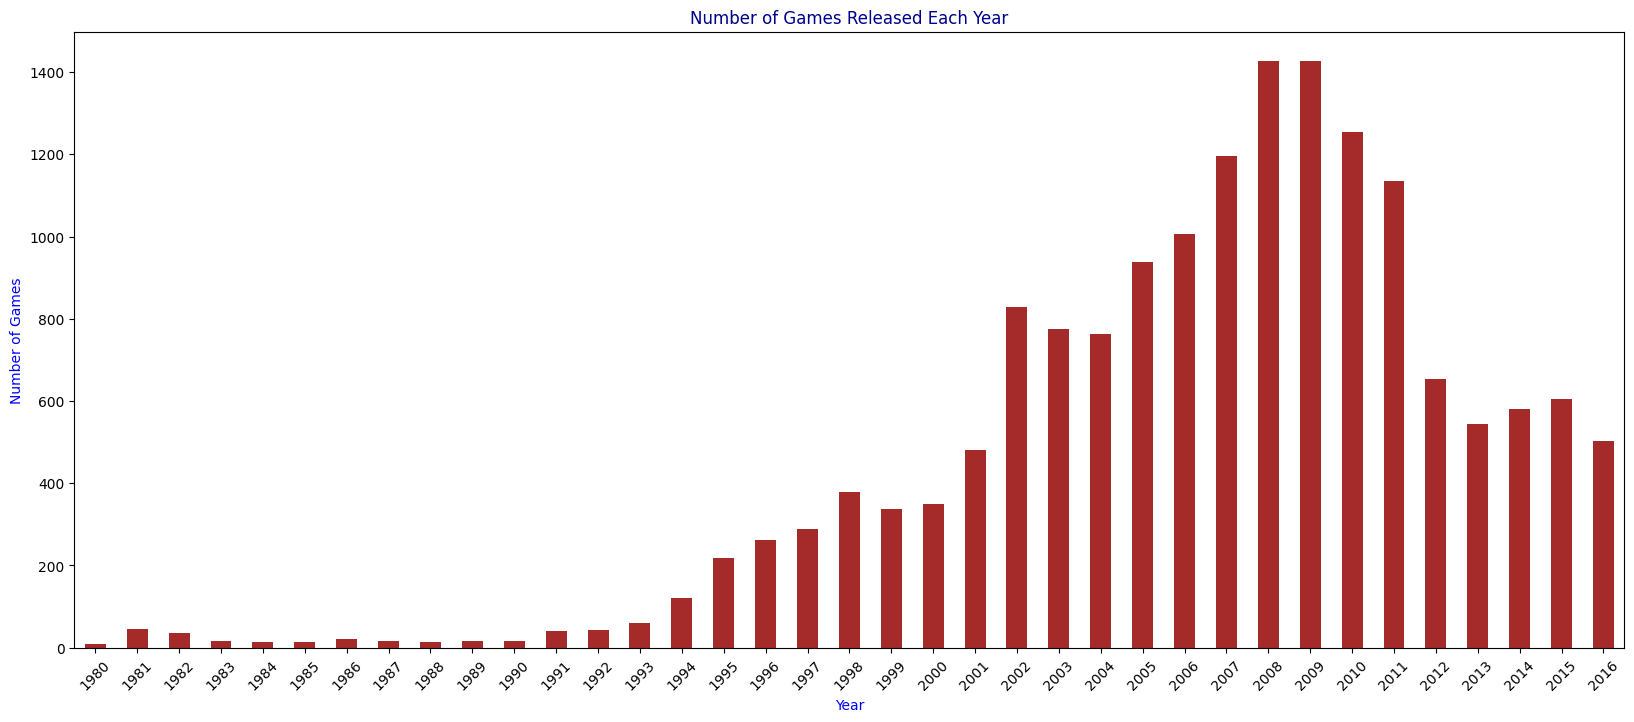

In [16]:
# Plotting Number of Games Released Each Year
plt.figure(figsize=(20, 8))
games_per_year.plot(kind='bar', color='brown')
plt.title('Number of Games Released Each Year', color = 'darkblue')
plt.xlabel('Year', color="blue")
plt.ylabel('Number of Games', color="blue")
plt.xticks(rotation=45)
plt.show()

No not all the data from every peroid is significant. In the first 13 years the number of games released was insignificant compared with the following years.

### Sales by platform

In [17]:
# Calculating of sales by platform:
sales_by_platform = games_df.groupby('platform')['total_sale'].sum().sort_values(ascending=False)

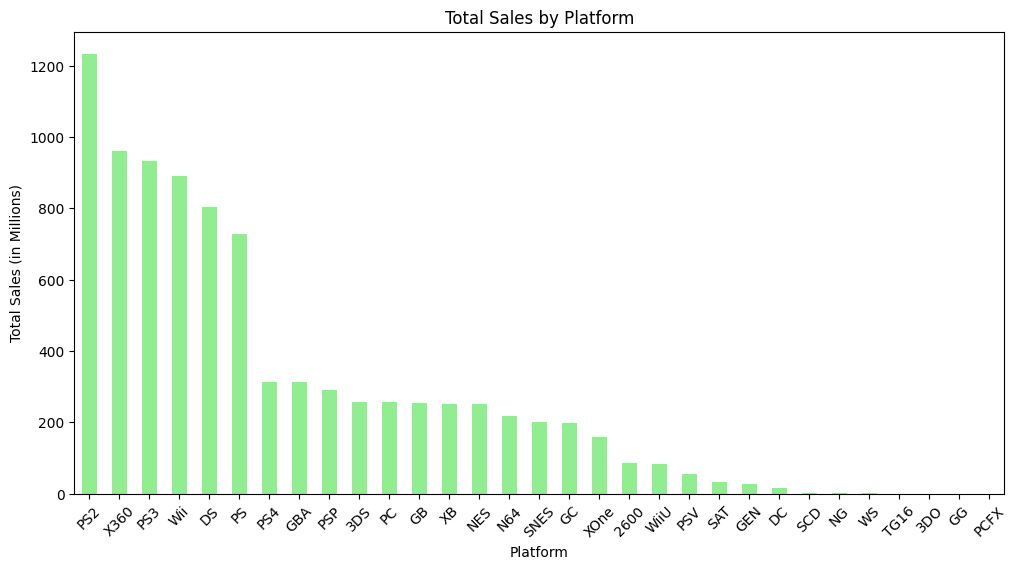

In [18]:
# Ploting Sales by Platform:
plt.figure(figsize=(12, 6))
sales_by_platform.plot(kind='bar', color='lightgreen')
plt.title('Total Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in Millions)')
plt.xticks(rotation=45)
plt.show()

The platform with the highest sales in PS2 with over 1200 millions in sale. The platforms with the greatest total sales are: PS2 X360, PS3. Wii, DS, PS.

In [19]:
# Counting the number of games released each for all platforms.

games_per_platform_year_all = games_df.groupby(['year_of_release', 'platform']).size().unstack(fill_value=0)

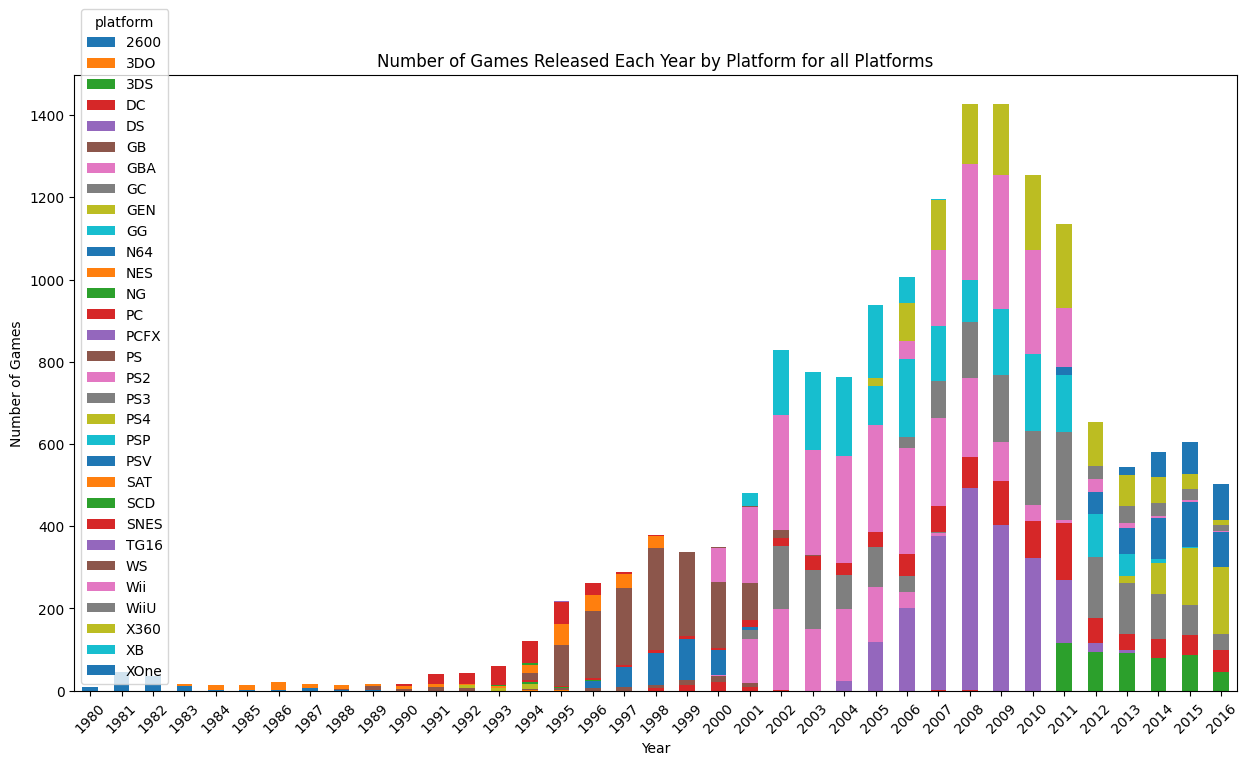

In [20]:
# Ploting the games_per_platform_year
games_per_platform_year_all.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Number of Games Released Each Year by Platform for all Platforms')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

WS use to be the most popular platform from 1995 to 2000 and now has 0 sales. TG16 was most popular from 2006 to 2010 and in 2014 to 2016 had 0 sales. It take an average of 7 to 10 years for old platforms to fade and new platforms to appear.

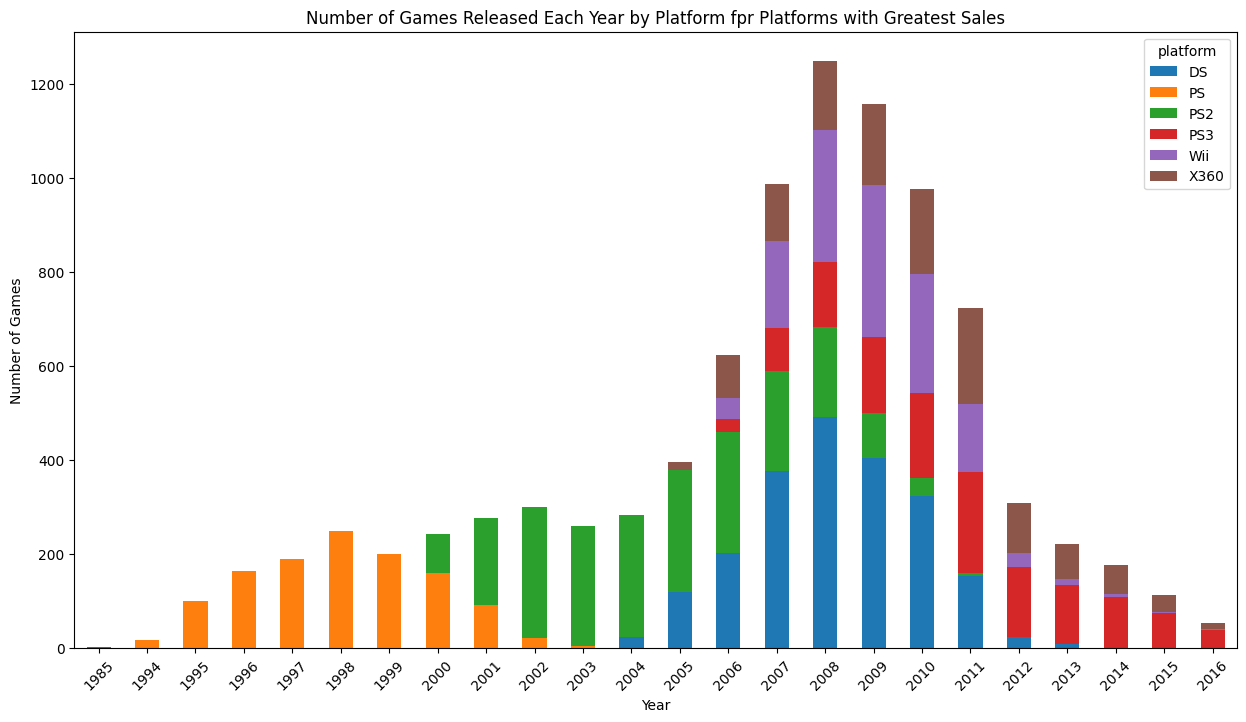

In [21]:
# Counting the number of games released each for the platforms with the greatest total sales.

selected_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']
filtered_games_df = games_df[games_df['platform'].isin(selected_platforms)]
games_per_platform_year_highsales = filtered_games_df.groupby(['year_of_release', 'platform']).size().unstack(fill_value=0)

# Ploting games_per_platform_year
games_per_platform_year_highsales.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Number of Games Released Each Year by Platform fpr Platforms with Greatest Sales')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

Based on my findings up to this stage I will continue to work with data from the 2010 to 2016 period as many of the platforms that were popular in prior years have phased out.

In [22]:
# Calculating lifespan of each platform:
lifespan = games_df.groupby('platform').agg({'year_of_release': ['min', 'max']})
lifespan['duration'] = lifespan['year_of_release']['max'] - lifespan['year_of_release']['min']

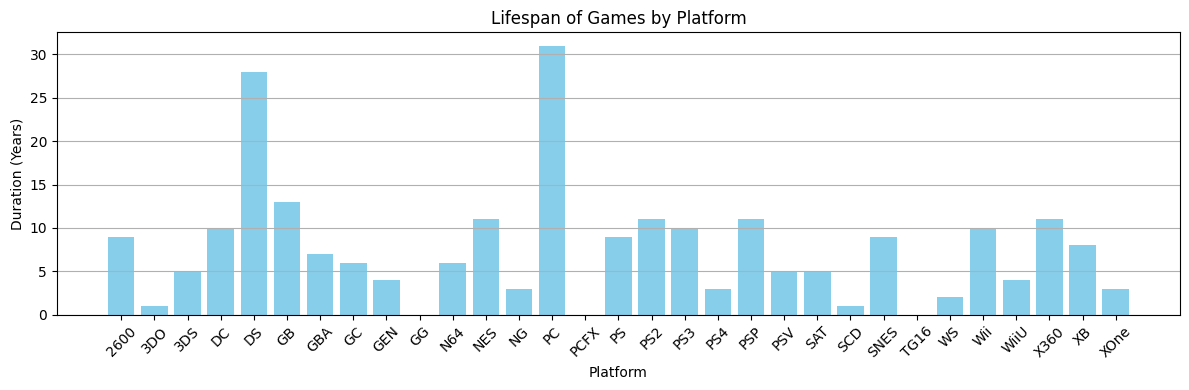

In [23]:
# Ploting the life span of each platform:

plt.figure(figsize=(12, 4))
plt.bar(lifespan.index, lifespan['duration'], color='skyblue')
plt.title('Lifespan of Games by Platform')
plt.xlabel('Platform')
plt.ylabel('Duration (Years)')
plt.xticks(rotation=45)  # Rotate platform names for better readability
plt.grid(axis='y')
plt.tight_layout()  # Adjust layout
plt.show()

The platforms with the longest life span are PC and DS with a lifespan of over 25 years. Followed by GB, NIES,PS2, PSP, X360 with a lifespan of over 10 years.

### Sales by Genre

In [24]:
# Filter the DataFrame for the years 2010 to 2016
filtered_games_df = games_df[(games_df['year_of_release'] >= 2010) & (games_df['year_of_release'] <= 2016)]

# Calculating sales distribution by genre:
sales_by_genre = filtered_games_df.groupby('genre')['total_sale'].sum().sort_values(ascending=False)
print(sales_by_genre)

genre
Action          673.09
Shooter         479.74
Sports          328.39
Role-Playing    315.28
Misc            234.56
Racing          122.68
Platform        119.72
Fighting         81.59
Simulation       71.75
Adventure        61.00
Strategy         35.84
Puzzle           20.60
Name: total_sale, dtype: float64


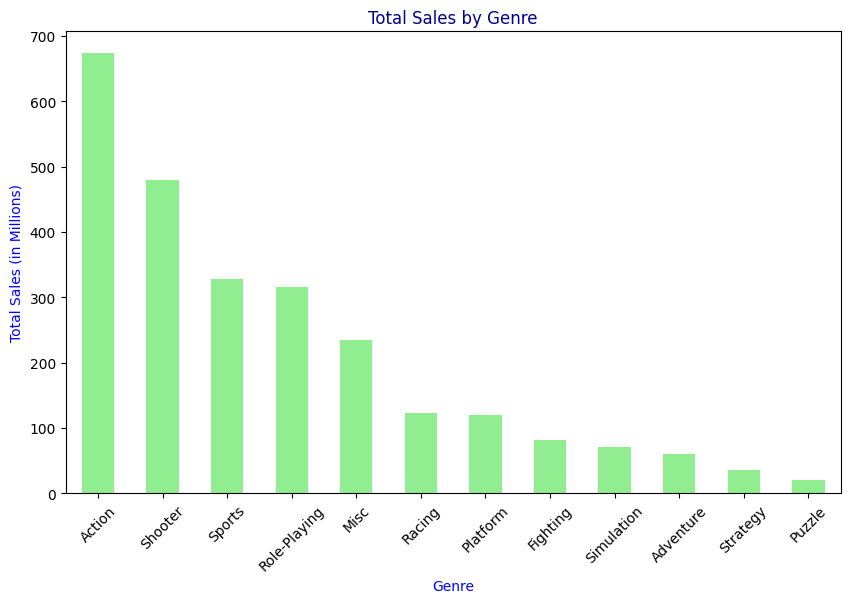

In [25]:
# Plotting the total sales by genre distribution:

plt.figure(figsize=(10, 6))
sales_by_genre.plot(kind='bar', color='lightgreen')
plt.title('Total Sales by Genre', color='darkblue')
plt.xlabel('Genre', color='blue')
plt.ylabel('Total Sales (in Millions)', color='blue')
plt.xticks(rotation=45)
plt.show()

The genres with the greatest sales are: action, sports, shooter, role-playing.

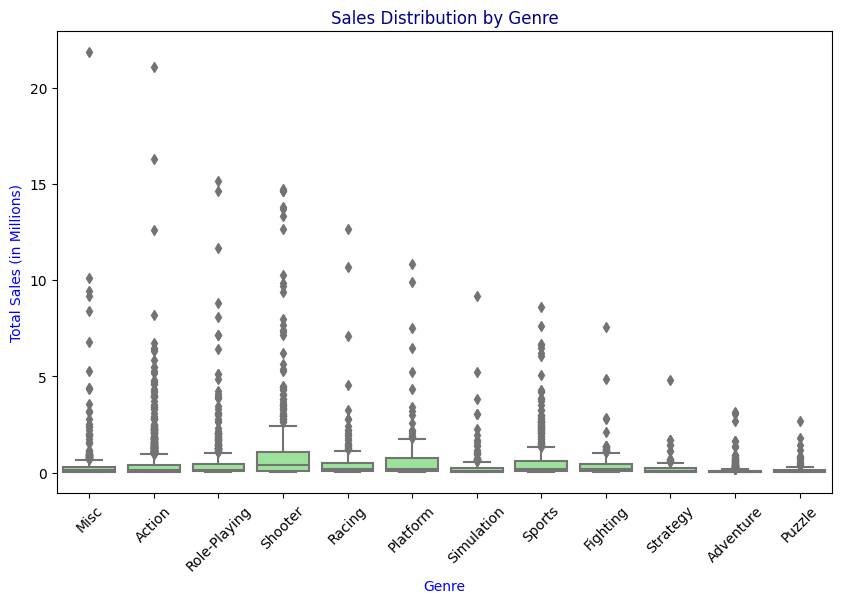

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='total_sale', data=filtered_games_df, color='lightgreen')  # Use
plt.title('Sales Distribution by Genre', color='darkblue')
plt.xlabel('Genre', color='blue')
plt.ylabel('Total Sales (in Millions)', color='blue')
plt.xticks(rotation=45)
plt.show()

### Corelation between User Score and Sales for the PS platform

Correlation between User Score and Total Sales for PS platform: 0.30


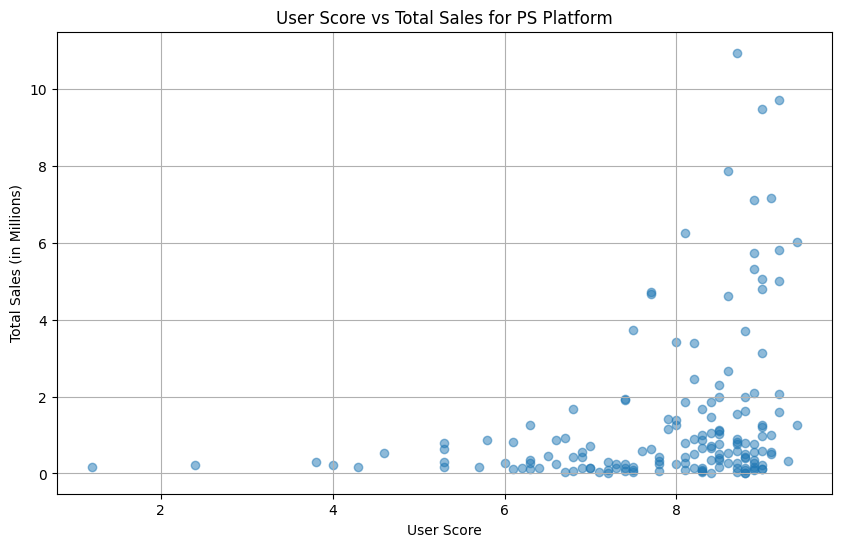

In [27]:
# Filtering the DataFrame for the PS platform
ps_games_df = games_df[games_df['platform'] == 'PS']

# Calculating the correlation between user_score and total_sales for the PS platform
correlation = ps_games_df[['user_score', 'total_sale']].corr().iloc[0, 1]
print(f'Correlation between User Score and Total Sales for PS platform: {correlation:.2f}')

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(ps_games_df['user_score'], ps_games_df['total_sale'], alpha=0.5)
plt.title('User Score vs Total Sales for PS Platform')
plt.xlabel('User Score')
plt.ylabel('Total Sales (in Millions)')
plt.grid(True)
plt.show()

There is a positive correlation between user score and sales for the PS platform

### Correlation between user_score and total_sales

Correlation between User Score and Total Sales: 0.09


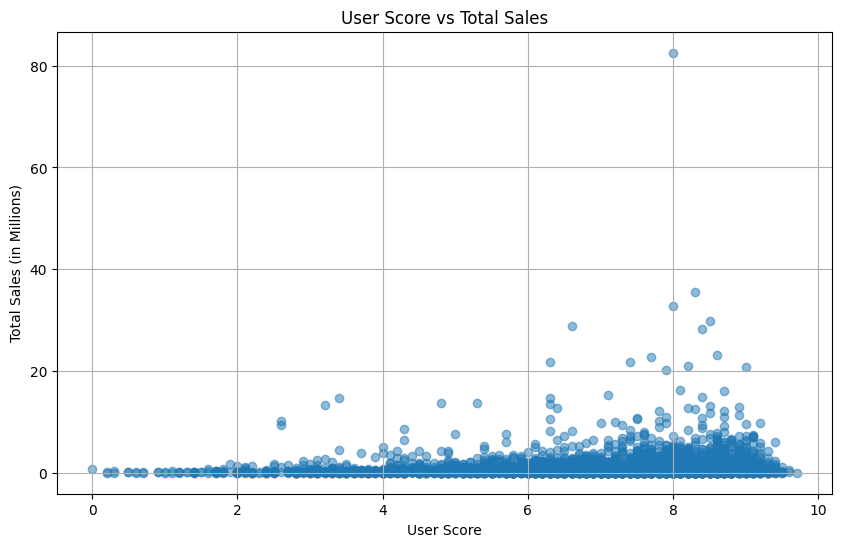

In [28]:
# Correlation between user_score and total_sales
correlation = games_df[['user_score', 'total_sale']].corr().iloc[0, 1]
print(f'Correlation between User Score and Total Sales: {correlation:.2f}')

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(games_df['user_score'], games_df['total_sale'], alpha=0.5)
plt.title('User Score vs Total Sales')
plt.xlabel('User Score')
plt.ylabel('Total Sales (in Millions)')
plt.grid(True)
plt.show()

There is a very slight positive correlation between User Score and Total Sales. This indicates that increases in user score do not have a significant impact on total sales.

## User Profile Creation

In [29]:
# Creating user profiles for each region
regions = ['na_sales', 'eu_sales', 'jp_sales']
for region in regions:
    top_platforms = games_df.groupby('platform')[region].sum().nlargest(5)
    top_genres = games_df.groupby('genre')[region].sum().nlargest(5)
    print(f'Top Platforms in {region}:\n{top_platforms}\n')
    print(f'Top Genres in {region}:\n{top_genres}\n')

Top Platforms in na_sales:
platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64

Top Genres in na_sales:
genre
Action      863.17
Sports      671.20
Shooter     584.83
Platform    444.44
Misc        399.57
Name: na_sales, dtype: float64

Top Platforms in eu_sales:
platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
PS      212.39
Name: eu_sales, dtype: float64

Top Genres in eu_sales:
genre
Action     510.99
Sports     371.33
Shooter    314.52
Racing     234.49
Misc       210.60
Name: eu_sales, dtype: float64

Top Platforms in jp_sales:
platform
DS      175.02
PS      139.78
PS2     137.54
SNES    116.55
3DS     100.62
Name: jp_sales, dtype: float64

Top Genres in jp_sales:
genre
Role-Playing    353.39
Action          160.14
Sports          134.93
Platform        130.71
Misc            107.02
Name: jp_sales, dtype: float64



North America (na_sales): Action and Sports genres dominate, with Xbox 360 and PS2 as top platforms.
Europe (eu_sales): Similar to North America but with a stronger presence of PS2 and PS3, indicating a preference for PlayStation platforms.
Japan (jp_sales): A distinct preference for Role-Playing games, with the DS leading in platform sales, highlighting cultural differences in gaming preferences.

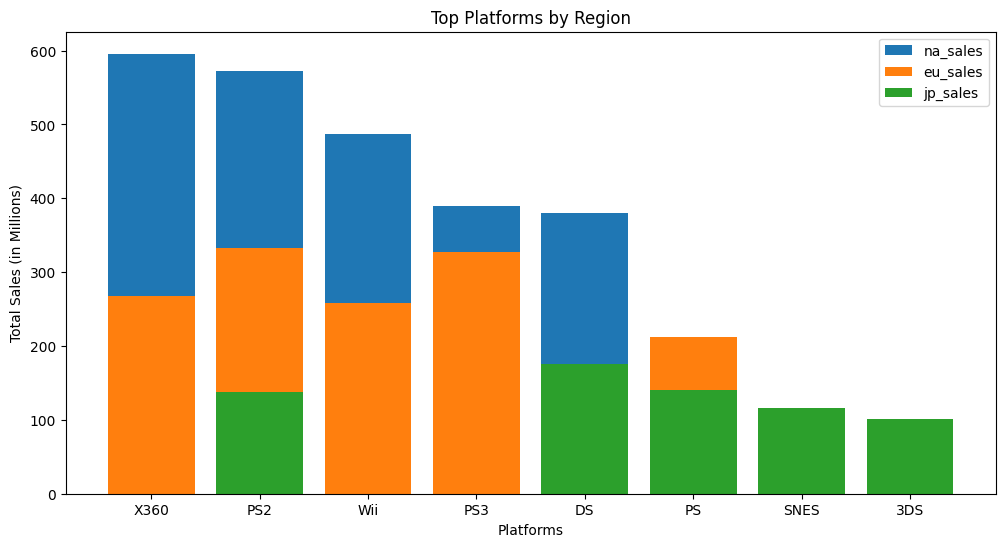

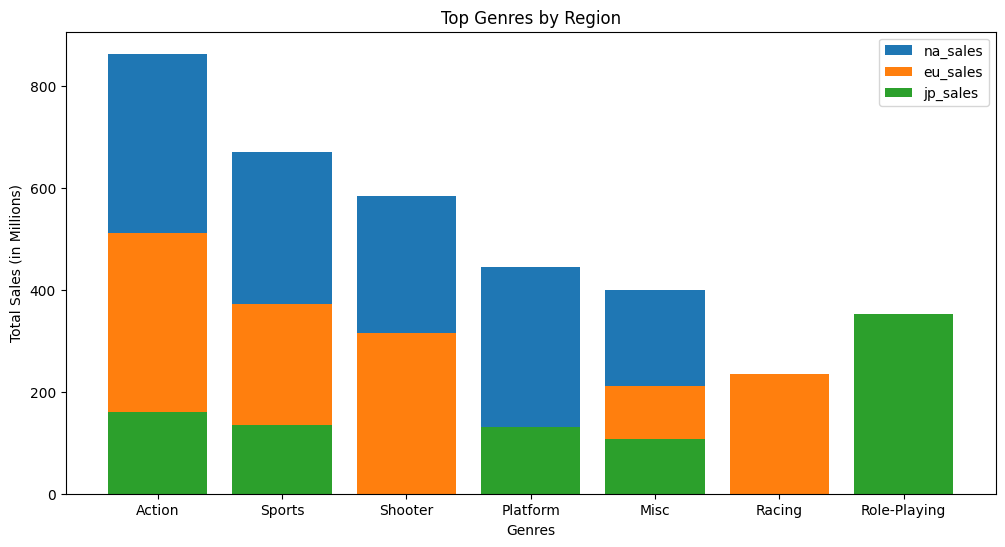

In [30]:
regions = ['na_sales', 'eu_sales', 'jp_sales']
top_platforms = {}
top_genres = {}

for region in regions:
    top_platforms[region] = games_df.groupby('platform')[region].sum().nlargest(5)
    top_genres[region] = games_df.groupby('genre')[region].sum().nlargest(5)

# Plotting Top Platforms
plt.figure(figsize=(12, 6))
for region in regions:
    plt.bar(top_platforms[region].index, top_platforms[region].values, label=region)
plt.title('Top Platforms by Region')
plt.xlabel('Platforms')
plt.ylabel('Total Sales (in Millions)')
plt.legend()
plt.show()

# Plotting Top Genres
plt.figure(figsize=(12, 6))
for region in regions:
    plt.bar(top_genres[region].index, top_genres[region].values, label=region)
plt.title('Top Genres by Region')
plt.xlabel('Genres')
plt.ylabel('Total Sales (in Millions)')
plt.legend()
plt.show()

## Hypothesis Testing

### Average user ratings of the Xbox One and PC platforms are the same. 

Null Hypothesis (H0): The average user ratings of the Xbox One and PC platforms are equal.
Alternative Hypothesis (H1): The average user ratings of the Xbox One and PC platforms are not equal. 
Chosen Alpha Level: α=0.05 This level provides a balance between being too lenient and too strict in testing hypotheses.

In [31]:
# Null Hypothesis: Average user ratings of the Xbox One and PC platforms are the same
xbox_one_scores = filtered_games_df[filtered_games_df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = filtered_games_df[filtered_games_df['platform'] == 'PC']['user_score'].dropna()
t_stat, p_value = stats.ttest_ind(xbox_one_scores, pc_scores)
print(f'T-test for Xbox One and PC: T-statistic = {t_stat}, P-value = {p_value}')

T-test for Xbox One and PC: T-statistic = 0.023828344764552412, P-value = 0.980998110649032


Since the P-value is significantly greater than 0.05, we fail to reject the null hypothesis. This suggests that there is no statistically significant difference in average user ratings between the Xbox One and PC platforms.

### Average user ratings for the Action and Sports genres are different.

In [32]:
# Null Hypothesis: Average user ratings for Action and Sports genres are different
action_scores = filtered_games_df[filtered_games_df['genre'] == 'Action']['user_score'].dropna()
sports_scores = filtered_games_df[filtered_games_df['genre'] == 'Sports']['user_score'].dropna()

t_stat_genre, p_value_genre = stats.ttest_ind(action_scores, sports_scores)
print(f'T-test for Action and Sports genres: T-statistic = {t_stat_genre}, P-value = {p_value_genre}')

T-test for Action and Sports genres: T-statistic = 9.026177597381961, P-value = 7.839124224330309e-19


The p-value is less than 0.05 we can reject the null hypothesis indicating that there are significant differences in the users ratings for the action and sports groups

This project involved a comprehensive analysis of video game data, focusing on user ratings across different platforms and genres. The analysis included data preparation, exploratory data analysis, and hypothesis testing to draw meaningful conclusions from the dataset.

Data Preparation:

The dataset was cleaned and preprocessed effectively, addressing missing values and converting data types as necessary. This ensured the integrity of the data for subsequent analyses.

Exploratory Data Analysis (EDA):

The analysis revealed trends in game releases over the years, highlighting the rise and fall of various gaming platforms.
Sales analysis showed that the PS2 had the highest total sales, followed by other platforms like X360 and PS3.
The genre analysis indicated that Action games generated the highest sales, followed by Sports games.

Correlation Analysis:

There is a very slight positive correlation between User Score and Total Sales. This indicates that increases in user score do not have a significant impact on total sales.

Hypothesis Testing:

Hypothesis 1: Since the P-value is significantly greater than 0.05, we fail to reject the null hypothesis. This suggests that there is no statistically significant difference in average user ratings between the Xbox One and PC platforms.

Hypothesis 2: The p-value is less than 0.05 therefore we can reject the null hypothesis indicating that there are significant differences in the users ratings for the action and sports groups